In [2]:
!pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
branca                  0.8.2
certifi                 2026.2.25
charset-normalizer      3.4.5
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
folium                  0.20.0
fonttools               4.61.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.11.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
Jinja2                  3.1.6
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.4.9
MarkupSafe              3.0.3
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.2
packaging               26.0
pandas                  3.0.1
parso                  

In [3]:
!pip install pgeocode


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install -U folium


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!python -m pip install -U folium


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install -U pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from typing import List

In [10]:
pd.__version__

'3.0.1'

In [11]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [12]:
# ============================================
# TASK 1 - DATA LOADING
# ============================================

In [13]:
df = pd.read_csv('data/cars.csv')

In [14]:
df.shape

(2830, 15)

In [15]:
df.columns

Index(['Unnamed: 0', 'mpg', 'milage', 'maketype', 'car_id', 'region', 'price',
       'make', 'type', 'scrapedate', 'alder', 'ccm2', 'doors', 'aldercat',
       'navn'],
      dtype='str')

In [16]:
df.dtypes

Unnamed: 0      int64
mpg           float64
milage        float64
maketype          str
car_id          int64
region            str
price         float64
make              str
type              str
scrapedate        str
alder           int64
ccm2          float64
doors             str
aldercat          str
navn              str
dtype: object

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830 entries, 0 to 2829
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2830 non-null   int64  
 1   mpg         2791 non-null   float64
 2   milage      2830 non-null   float64
 3   maketype    2830 non-null   str    
 4   car_id      2830 non-null   int64  
 5   region      2821 non-null   str    
 6   price       2830 non-null   float64
 7   make        2830 non-null   str    
 8   type        2830 non-null   str    
 9   scrapedate  2830 non-null   str    
 10  alder       2830 non-null   int64  
 11  ccm2        2822 non-null   float64
 12  doors       2830 non-null   str    
 13  aldercat    2830 non-null   str    
 14  navn        2821 non-null   str    
dtypes: float64(4), int64(3), str(8)
memory usage: 331.8 KB


In [18]:
df.sample(5)

,Unnamed: 0,mpg,milage,maketype,car_id,region,price,make,type,scrapedate,alder,ccm2,doors,aldercat,navn
978,978,14.900000,89000.000000,"Toyota Verso 1,8 VVT-i T2 Premium 7prs 5d",5495090,Syd- og Sønderjylland,209900.000000,Toyota,Verso,2022-11-08 22:29:38.772658,5,1800.000000,5d,veteran,Region Syddanmark
2808,2808,15.600000,219000.000000,"Ford Fusion 1,4 Trend 5d",4939501,Nordsjælland,32000.000000,Ford,Fusion,2022-11-08 22:29:38.772658,19,1400.000000,5d,veteran,Region Sjælland
867,867,20.400000,69000.000000,"Ford Ka 1,2 Trend+ 3d",5510299,Nordjylland,52900.000000,Ford,Ka,2022-11-08 22:29:38.772658,7,1200.000000,3d,veteran,Region Nordjylland
1847,1847,21.600000,37000.000000,"Toyota Yaris 1,5 VVT-iE T3 Premium 5d",5595042,Nordsjælland,159900.000000,Toyota,Yaris,2022-11-08 22:29:38.772658,3,1500.000000,5d,veteran,Region Sjælland
20,20,22.200000,91000.000000,"Ford Fiesta 1,0 EcoBoost Vignale 5d",5529475,Østjylland,159700.000000,Ford,Fiesta,2022-11-08 22:29:38.772658,4,1000.000000,5d,veteran,Region Midtjylland


In [19]:
df.isna().sum()

Unnamed: 0     0
mpg           39
milage         0
maketype       0
car_id         0
region         9
price          0
make           0
type           0
scrapedate     0
alder          0
ccm2           8
doors          0
aldercat       0
navn           9
dtype: int64

In [20]:
# ============================================
# TASK 2 - REMOVING DUPLICATES, NAN AND UNNECESSARY COLUMNS
# ============================================

In [21]:
df = df.drop(columns=['Unnamed: 0', 'maketype', 'navn', 'car_id', 'scrapedate', 'aldercat'])

In [22]:
df.sample(5)

,mpg,milage,region,price,make,type,alder,ccm2,doors
959,16.100000,163000.000000,Syd- og Sønderjylland,149900.000000,Ford,Kuga,7,1500.000000,5d
1522,16.400000,68000.000000,København,419900.000000,Volvo,XC40,3,2000.000000,5d
1488,20.800000,103000.000000,Syd- og Sønderjylland,127400.000000,Ford,Focus,7,1000.000000,5d
434,9.200000,46000.000000,Syd- og Sønderjylland,255855.000000,Ford,Mustang,48,4900.000000,2d
2770,11.400000,463000.000000,Østjylland,19800.000000,Volvo,V70,21,2400.000000,5d


In [23]:
df.duplicated().sum()

np.int64(23)

In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.isnull().sum()

mpg       39
milage     0
region     9
price      0
make       0
type       0
alder      0
ccm2       8
doors      0
dtype: int64

In [27]:
df = df.dropna(subset=['mpg', 'region', 'ccm2'])

In [28]:
df.sample(10)

,mpg,milage,region,price,make,type,alder,ccm2,doors
1358,26.300000,95000.000000,København,74900.000000,Toyota,Aygo,7,1000.000000,5d
1763,23.300000,161000.000000,Østjylland,61800.000000,Ford,Fiesta,9,1000.000000,5d
2777,21.600000,21600.000000,Syd- og Sønderjylland,239900.000000,Ford,Puma,1,1000.000000,5d
778,24.200000,0.000000,København,209900.000000,Ford,Fiesta,0,1000.000000,5d
1238,20.400000,196000.000000,Syd- og Sønderjylland,34900.000000,Ford,Ka,9,1200.000000,3d
1095,26.300000,69850.000000,København,84700.000000,Toyota,Aygo,5,1000.000000,5d
270,21.600000,20000.000000,Syd- og Vestsjælland,159850.000000,Toyota,Yaris,3,1500.000000,5d
883,16.200000,47000.000000,Nordjylland,439900.000000,Volvo,V60,2,2000.000000,5d
333,23.300000,83000.000000,Vestjylland,179900.000000,Ford,Fiesta,4,1000.000000,5d
987,20.800000,166000.000000,Syd- og Vestsjælland,99900.000000,Ford,Focus,7,1000.000000,5d


In [29]:
# ============================================
# TASK 3 - EXPLORE
# ============================================

In [30]:
print("\nMake distribution:\n", df['make'].value_counts())
print("\nRegion distribution:\n", df['region'].value_counts())
print("\nDoors distribution:\n", df['doors'].value_counts())


Make distribution:
 make
Ford      1538
Toyota     981
Volvo      240
Name: count, dtype: int64

Region distribution:
 region
Syd- og Sønderjylland    488
Syd- og Vestsjælland     482
København                464
Østjylland               460
Nordjylland              265
Fyn                      259
Vestjylland              171
Nordsjælland             156
Lolland-Falster           14
Name: count, dtype: int64

Doors distribution:
 doors
5d    2408
3d     187
4d     120
2d      44
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

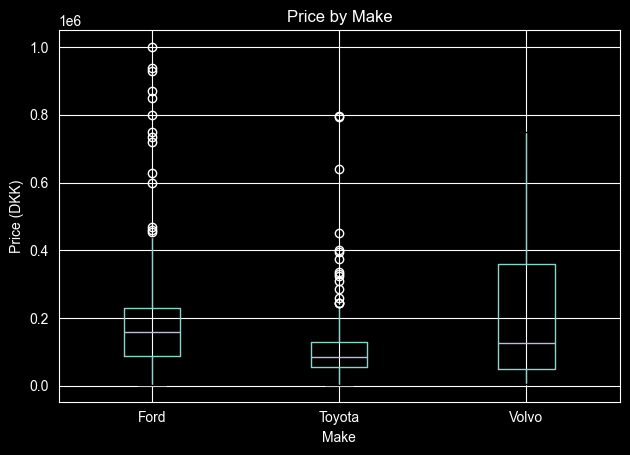

In [31]:
plt.figure(figsize=(8, 5))
df.boxplot(column='price', by='make')
plt.title('Price by Make')
plt.suptitle('')
plt.xlabel('Make')
plt.ylabel('Price (DKK)')
plt.tight_layout()
plt.show()

In [32]:
# REMOVING OUTLIERS

# ── 1. BEFORE ─────────────────────────────────────────────
print("Before outlier removal:", df.shape)
print(df[['price', 'milage', 'mpg', 'ccm2', 'alder']].describe())

# ── 2. IQR FUNCTION ───────────────────────────────────────
def remove_outliers(df, column, factor=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[column] < (q1 - factor * iqr)) | (df[column] > (q3 + factor * iqr))]
    df = df.drop(outliers.index)
    return df

# ── 3. REMOVE OUTLIERS ────────────────────────────────────
df = remove_outliers(df, 'price', 1.5)
df = remove_outliers(df, 'milage', 1.5)
df = remove_outliers(df, 'mpg', 1.5)
df = remove_outliers(df, 'ccm2', 1.5)
df = remove_outliers(df, 'alder', 1.5)

# ── 4. AFTER ──────────────────────────────────────────────
print("\nAfter outlier removal:", df.shape)
print(df[['price', 'milage', 'mpg', 'ccm2', 'alder']].describe())

Before outlier removal: (2759, 9)
              price        milage         mpg        ccm2       alder
count   2759.000000   2759.000000 2759.000000 2759.000000 2759.000000
mean  144716.805364 101298.413918   19.811200 1336.100036    7.345777
std   109145.734123  77681.726614    4.707578  526.834113    6.536508
min     2799.000000      0.000000    6.900000 1000.000000   -1.000000
25%    69450.000000  42000.000000   16.100000 1000.000000    3.000000
50%   119900.000000  89000.000000   20.800000 1000.000000    6.000000
75%   194900.000000 143500.000000   23.300000 1500.000000   10.000000
max   999995.000000 510300.000000   39.300000 5400.000000   67.000000

After outlier removal: (2443, 9)
              price        milage         mpg        ccm2       alder
count   2443.000000   2443.000000 2443.000000 2443.000000 2443.000000
mean  138398.232910  90867.860827   20.751453 1211.420385    6.160868
std    80798.328081  63928.848570    4.011675  295.118885    4.225318
min     2799.000000   

In [33]:
# Correlation

In [34]:
df.columns

Index(['mpg', 'milage', 'region', 'price', 'make', 'type', 'alder', 'ccm2',
       'doors'],
      dtype='str')

In [35]:
corr = df.corr(method='pearson', numeric_only=True)
print(corr)

             mpg    milage     price     alder      ccm2
mpg     1.000000 -0.451313 -0.033972 -0.513281 -0.803371
milage -0.451313  1.000000 -0.637119  0.787784  0.370576
price  -0.033972 -0.637119  1.000000 -0.749252 -0.000508
alder  -0.513281  0.787784 -0.749252  1.000000  0.419596
ccm2   -0.803371  0.370576 -0.000508  0.419596  1.000000


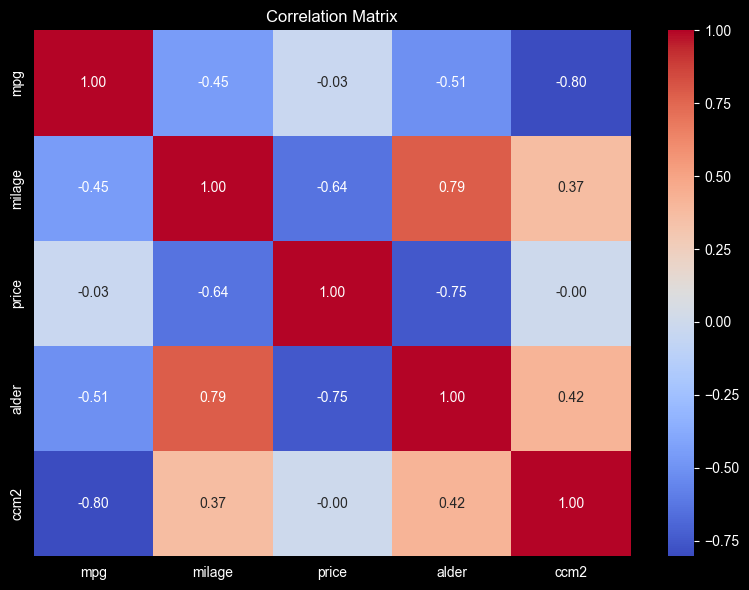

In [36]:
# ── 2. HEATMAP ────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [37]:
# ── 1. SELECT NUMERIC COLUMNS ─────────────────────────────
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(num_cols)

['mpg', 'milage', 'price', 'alder', 'ccm2']


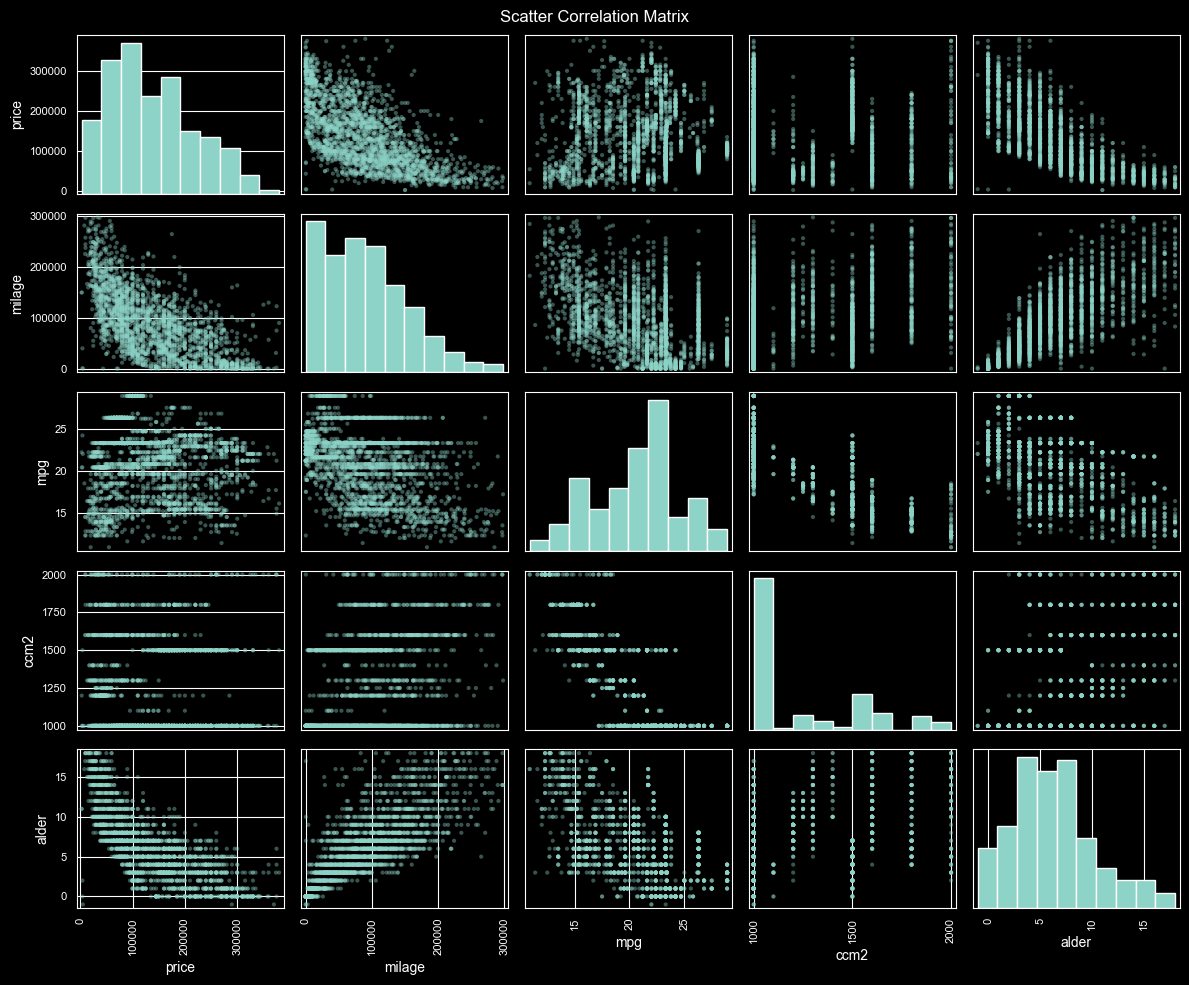

In [38]:
# ── 2. SCATTER MATRIX ─────────────────────────────────────
price_cols = df[['price', 'milage', 'mpg', 'ccm2', 'alder']]

pd.plotting.scatter_matrix(price_cols, alpha=0.4, figsize=(12, 10), diagonal='hist')
plt.suptitle('Scatter Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
"""Task 1 - Data Wrangling and Exploration - Summary

The dataset was loaded from a .csv file with 2830 rows and 14 columns. Cleaning involved dropping 6 redundant or uninformative columns,
removing rows with missing values in mpg, region and ccm2, and resetting the index.
Exploring the data revealed that Ford is the most represented brand with 1538 cars, followed by Toyota with 981 and Volvo with 240.
Geographically, the listings are spread across 9 Danish regions, with Syd- og Sønderjylland and Syd- og Vestsjælland being the most common.
The majority of cars are 5-door models, making up 2408 out of 2759 listings."""

In [43]:
# Task 2 - Supvervised learning by regression

In [ ]:
# Dependent (target) variable:
# Price — most practical for vendors/resellers
# Mpg — useful for environmental/economy analysis

# Independent (feature) variables:
# Milage — more km = lower price
# Alder — older = lower price
# Ccm2 — engine size affects both price and fuel consumption
# Make — brand has strong price influence
# Type — model type affects price
# Doors — body style
# Region — location affects market price

Train size: (1954, 56)
Test size:  (489, 56)

── Error Measures ──
MAE:  20,483 DKK
MSE:  904,693,739
RMSE: 30,078 DKK
R²:   0.8702


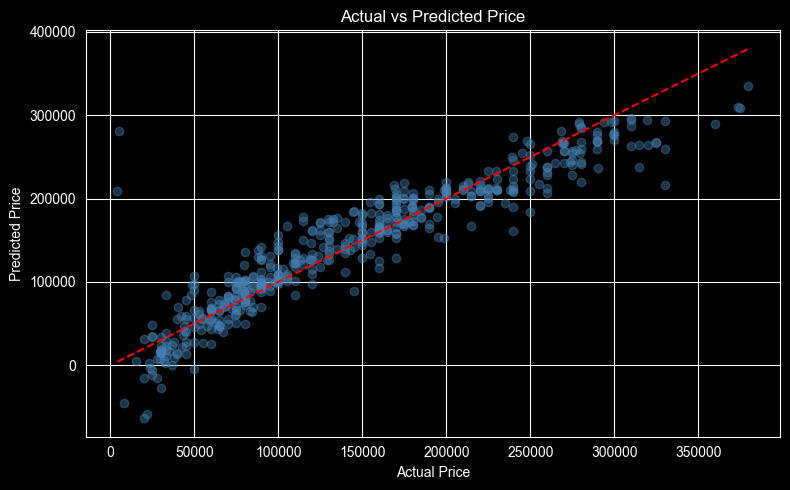

In [39]:
# ── 1. ENCODE CATEGORICALS ────────────────────────────────
df_encoded = pd.get_dummies(df, columns=['make', 'type', 'doors', 'region'])

# ── 2. DEFINE DEPENDENT AND INDEPENDENT VARIABLES ─────────
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# ── 3. SPLIT 80/20 ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

# ── 4. TRAIN MODEL ────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── 5. PREDICT ────────────────────────────────────────────
y_pred = model.predict(X_test)

# ── 6. EVALUATE ───────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n── Error Measures ──")
print(f"MAE:  {mae:,.0f} DKK")
print(f"MSE:  {mse:,.0f}")
print(f"RMSE: {rmse:,.0f} DKK")
print(f"R²:   {r2:.4f}")

# ── 7. VISUALIZE ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.tight_layout()
plt.show()

In [44]:
# Task 3 - Unsupervised machine learning for clustering

In [47]:
# ── 1. SELECT FEATURES FOR CLUSTERING ────────────────────
cluster_df = df[['price', 'milage', 'mpg', 'ccm2', 'alder']].copy()

In [48]:
# ── 2. SCALE THE DATA ─────────────────────────────────────
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

In [49]:
# ── 3. FIND OPTIMAL K (ELBOW METHOD) ──────────────────────
inertia = []
k_range = range(2, 11)

In [50]:
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

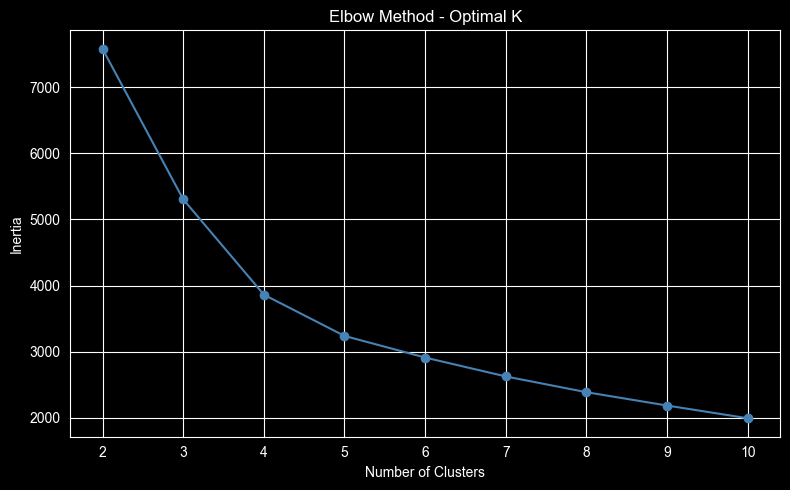

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [52]:
# ── 4. TRAIN KMEANS WITH OPTIMAL K ────────────────────────
# Change k based on elbow plot
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(cluster_scaled)

In [53]:
# ── 5. ANALYZE CLUSTERS ───────────────────────────────────
print(df.groupby('cluster')[['price', 'milage', 'mpg', 'ccm2', 'alder']].mean().round(0))

                price        milage       mpg        ccm2    alder
cluster                                                           
0       204179.000000  30082.000000 23.000000 1084.000000 2.000000
1       132198.000000 136849.000000 15.000000 1622.000000 9.000000
2        81317.000000 115274.000000 23.000000 1041.000000 8.000000


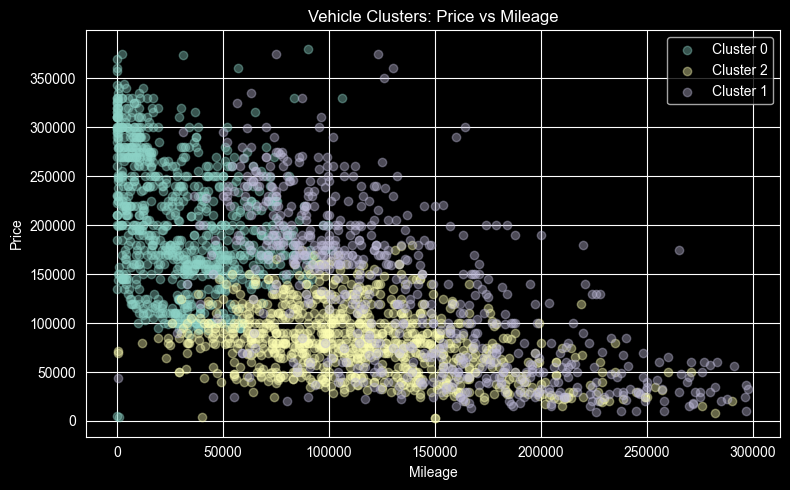

In [54]:
# ── 6. VISUALIZE ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['milage'], subset['price'], alpha=0.4, label=f'Cluster {cluster}')

plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Vehicle Clusters: Price vs Mileage')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
print(df.groupby('cluster')[['price', 'milage', 'mpg', 'ccm2', 'alder']].mean().round(0))

                price        milage       mpg        ccm2    alder
cluster                                                           
0       204179.000000  30082.000000 23.000000 1084.000000 2.000000
1       132198.000000 136849.000000 15.000000 1622.000000 9.000000
2        81317.000000 115274.000000 23.000000 1041.000000 8.000000


In [57]:
"""Task 3 – Unsupervised machine learning for clustering - Summary

K-Means clustering was applied to segment vehicles based on price, mileage, fuel efficiency, engine size and age. Data was normalized using StandardScaler and the Elbow Method determined K=3 as optimal.
Three distinct segments were identified. Cluster 0 represents new premium cars (avg. 204,179 DKK, 30,082 km, 2 years old). Cluster 1 covers mid-range older cars (avg. 132,198 DKK, 136,849 km, 9 years old). Cluster 2 is the budget segment (avg. 81,317 DKK, 115,274 km, 8 years old). The results align with real world expectations where price is strongly driven by age and mileage."""

In [ ]:
# Task 4 - Supervised machine learning for classification

In [59]:
# ── 1. CREATE PRICE SEGMENTS ──────────────────────────────
df['price_segment'] = df['cluster'].map({0: 'Premium', 1: 'Mid-range', 2: 'Budget'})

In [60]:
# ── 2. PREPARE DATA ───────────────────────────────────────
df_clf = pd.get_dummies(df, columns=['make', 'type', 'doors', 'region'])
X = df_clf.drop(columns=['price', 'cluster', 'price_segment'])
y = df_clf['price_segment']

In [61]:
# ── 3. SPLIT, TRAIN, PREDICT ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [62]:
# ── 4. EVALUATE ───────────────────────────────────────────
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Budget       0.98      0.99      0.98       176
   Mid-range       0.95      0.99      0.97       125
     Premium       0.99      0.95      0.97       188

    accuracy                           0.97       489
   macro avg       0.97      0.98      0.97       489
weighted avg       0.97      0.97      0.97       489



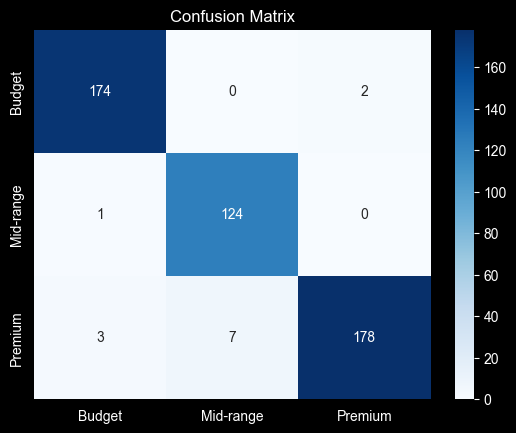

In [63]:

# ── 5. CONFUSION MATRIX ───────────────────────────────────
sns.heatmap(confusion_matrix(y_test, y_pred, labels=['Budget', 'Mid-range', 'Premium']),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Budget', 'Mid-range', 'Premium'],
            yticklabels=['Budget', 'Mid-range', 'Premium'])
plt.title('Confusion Matrix')
plt.show()

In [ ]:
"""A Random Forest classifier was trained to classify vehicles into three price segments — Budget, Mid-range and Premium — based on the clusters identified in Task 3. The data was one-hot encoded and split 80/20 into training and test sets.
The model achieved an overall accuracy of 97%, with F1-scores of 0.98, 0.97 and 0.97 for Budget, Mid-range and Premium respectively. The confusion matrix confirmed that misclassifications were minimal, with Premium being the most difficult segment to classify due to its natural overlap with Mid-range. The results demonstrate that vehicle price segments can be predicted with high accuracy using features such as mileage, age, engine size and brand."""

In [ ]:
"""5. Implementation of the models"""

In [65]:
# ── SAVE MODELS ───────────────────────────────────────────
joblib.dump(model, 'regression_model.pkl')
joblib.dump(km, 'clustering_model.pkl')
joblib.dump(clf, 'classification_model.pkl')

print("Models saved successfully")

Models saved successfully


In [ ]:
# --- Demonstrate, visualise and explain their use for prediction ---

In [66]:
# ── LOAD MODELS ───────────────────────────────────────────
model = joblib.load('regression_model.pkl')
km    = joblib.load('clustering_model.pkl')
clf   = joblib.load('classification_model.pkl')

In [67]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']